# Milestone 1: Exploratory Data Analysis (EDA) of Machine Learning Solution Project

# I. Introduction
Introduce the dataset and the purpose of the Exploratory Data Analysis.
1. What is the dataset about? Provide a brief overview. The dataset contains information related to customer demographics, transactions, and social media interactions at FinMark Corporation. It aims to provide insights into customer behaviors, market trends, and interaction patterns across multiple platforms.
2. Why is this Exploratory Data Analysis important? EDA is crucial for understanding the structure of the dataset, identifying missing or inconsistent data, and detecting patterns or trends that can help improve customer segmentation and business strategies.
3. What are the goals or objectives? The goal is to gain insights into customer demographics, transaction patterns, and social media interactions and use these insights to enhance FinMark's marketing and customer segmentation strategies.
4. Who is the intended audience for this report? The intended audience includes business analysts, data scientists, and decision-makers at FinMark Corporation who are responsible for improving market trends understanding and customer segmentation strategies.

# II. Dataset Overview
Describe the basic characteristics and structure of the dataset.
1. How many variables (columns) and observations (rows) does the dataset contain?
2. What are each variable's data types (numeric, categorical, etc.)?
3. Are there any initial observations or peculiarities about the dataset's structure?

# III. Data Quality Check
Assess and summarize the quality of the data.
1. Which variables have missing values? How many missing values are there?
2. What methods were used to handle missing data (e.g., imputation, removal)?
3. What are the basic statistics (mean, median, min, max) for numeric variables?
4. What are the frequency counts or distributions for categorical variables?
5. Did you identify any outliers? How were outliers handled or interpreted?

In [6]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra
import scipy as sp
from scipy import stats
import scipy.cluster.hierarchy as sch
from itertools import combinations 
import regex
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [7]:
# Set pandas display options to ensure all columns are displayed in a single line
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a large width to avoid line breaks

In [8]:
# Load the datasets
contaminated_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/customer_demographics_contaminated.csv')
contaminated_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/customer_transactions_contaminated.csv')
contaminated_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/social_media_interactions_contaminated.csv')

# Define datasets and dataset_names
datasets = [contaminated_data1, contaminated_data2, contaminated_data3] #replace
dataset_names = ['customer_demographics','customer_transactions','social_media_interactions']
dataset_titles = ['Customer Demographics','Customer Transactions','Social Media Interactions']

# How many variables (columns) and observations (rows) does the dataset contain?

In [10]:
print("*********************************************************************************")
print("Milestone 1: Exploratory Data Analysis (EDA) of Machine Learning Solution Project") #replace
print("*********************************************************************************")

# Check for number of columns and rows for each dataset
print("\nDataset Overview")
for df, dataset_name in zip(datasets, dataset_names):
    print(f"{dataset_name} has {df.shape[1]} columns and {df.shape[0]} rows.")

*********************************************************************************
Milestone 1: Exploratory Data Analysis (EDA) of Machine Learning Solution Project
*********************************************************************************

Dataset Overview
customer_demographics has 6 columns and 3200 rows.
customer_transactions has 6 columns and 3200 rows.
social_media_interactions has 6 columns and 3200 rows.


# What are each variable's data types (numeric, categorical, etc.)?

In [12]:
# Check for data types
for df, dataset_name in zip(datasets, dataset_names):
    print(f"\nData types for each column in {dataset_name}:\n{df.dtypes}")


Data types for each column in customer_demographics:
CustomerID     object
Age            object
Gender         object
Location       object
IncomeLevel    object
SignupDate     object
dtype: object

Data types for each column in customer_transactions:
CustomerID         object
TransactionID      object
TransactionDate    object
Amount             object
ProductCategory    object
PaymentMethod      object
dtype: object

Data types for each column in social_media_interactions:
CustomerID         object
InteractionID      object
InteractionDate    object
Platform           object
InteractionType    object
Sentiment          object
dtype: object


1. Data types for each column in customer_demographics:

   
    CustomerID     object/categorical
    Age            object/numeric
    Gender         object/categorical
    Location       object/categorical
    IncomeLevel    object/categorical
    SignupDate     object/categorical

3. Data types for each column in customer_transactions:

   
    CustomerID         object/categorical
    TransactionID      object/categorical
    TransactionDate    object/categorical
    Amount             object/float
    ProductCategory    object/categorical
    PaymentMethod      object/categorical

5. Data types for each column in social_media_interactions:

   
    CustomerID         object/categorical
    InteractionID      object/categorical
    InteractionDate    object/categorical
    Platform           object/categorical
    InteractionType    object/categorical
    Sentiment          object/categorical

# Are there any initial observations or peculiarities about the dataset's structure?

‘customer_demographics_contaminated.csv’

    Customer ID: This is a unique identifier (UUID format), but there were duplicates found.
    Age: I found unrealistic values like -1 and 150; while there were also some marked as ‘Unknown’ and 291 null values.
    Gender: All were consistently tagged as either ‘Male’ or ‘Female’
    Location: A town name found to be a possible misspelling: e.g. Adamshire vs Adamsshire; Castillofort vs Castilloport 
    Income Level: Consistent naming and formatting (Low, Medium, High) although there were a 303 null values
    Signup Date: Consistent dd/mm/yyyy formatting; range is from July 2019 to June 2024


‘customer_transactions_contaminated.csv’

    Transaction ID: This is a unique identifier. There should be no duplicate transaction IDs but I found a total of 200 duplicate records.
    Transaction Date: Consistent dd/mm/yyyy formatting; range is from July 2022 to June 2024.
    Amount: There were unrealistic amounts like -100 and 0; while some were labeled as ‘Free’. There were 304 nulls.
    Product Category: Consistent naming and formatting (Automotive, Clothing, Electronics, Health & Beauty, and Home & Garden); while some were left blank (299).
    Payment Method: Consistent naming and formatting (Bank Transfer, Credit Card, Debit Card, PayPal); no blanks.	


'social_media_interactions_contaminated.csv’

    CustomerID: Consistent text formatting
    Interaction ID: This is a unique identifier. There should be no duplicate transaction IDs but I found a total of 200 duplicates.
    Interaction Date: Consistent dd/mm/yyyy formatting; range is from July 2023 to June 2024
    Platform: Consistent naming and formatting (Facebook, Instagram, Twitter); but there were also some that were left blank (311).
    Interaction Type: Consistent naming and formatting (Comment, Share, Like), no blanks.
    Sentiment: Consistent naming and formatting (Negative, Neutral, Positive, Very Negative, Very Positive, None) though with 329 missing values.


**********************************************************************************************************************************************************************************

Customer ID, Transaction ID, and Interaction ID all have the same alphanumeric format; even the same length of characters.

**********************************************************************************************************************************************************************************
Observations before first phase of deduplication:

    - Customer Demographics has 177 duplicate rows.
    - Customer Transactions has 185 duplicate rows.
    - Social Media Interactions has 180 duplicate rows.

Observations after first phase of deduplication:

    - Customer Demographics has 23 duplicate rows based on 'CustomerID'.
    - Customer Transactions has 15 duplicate rows based on 'TransactionID'.
    - Social Media Interactions has 20 duplicate rows based on 'InteractionID'.

Upon manual inspection of records that have duplicate unique IDs:

    - CustomerID duplicates (46 records) - either duplicate records have the same Age but different SignupDate (24 records) OR different Age but same SignupDate  (22 records)
    - TransactionID duplicates (30 records) - either duplicate records have the same TransactionDate but different Amount (16 records), different TransactionDate but same Amount (8 records), and varying TransactionDate and Amount (6 records)
    - InteractionID duplicates (40 records) - either duplicate records have the same InteractionDate but different Sentiment (18 records) or different InteractionDate but same Sentiment (22 records).
**********************************************************************************************************************************************************************************
Decision criteria for records that have duplicate unique IDs:
        
    i. CustomerID duplicates (46 records)
        1. For duplicate records that have the same Age but different SignupDate (24 records), I retained the one with the more recent SignupDate as it is more likely up-to-date.
        2. For duplicate records that have different Age but same SignupDate (22 records), I picked the more reasonable age and deleted the records with either -1, Unknown, or 150 value.
    ii. TransactionID duplicates (30 records)
        1. For duplicate records that have the same TransactionDate but different Amount (16 records):
            a. Positive Amount vs "Free" - retained record with positive Amount since there was a PaymentMethod indicated
            b. Positive Amount vs Zero - retained record with positive Amount since there was a PaymentMethod indicated
            c. Positive Amount vs -100 - deducted the -100 against positive Amount since this could possibly be a voucher, discount, or a refund; provided that the positive Amount is bigger than 100.
        2. For duplicate records that have different TransactionDate but same Amount (10 records), I retained the record with the more recent TransactionDate.
        3. For duplicate records that have varying TransactionDate and Amount (4 records), I deleted both records since it was hard to determine which record is more reliable.
    iii. InteractionID duplicates (40 records) - either duplicate records have the same InteractionDate but different Sentiment (18 records) or different InteractionDate but same Sentiment (22 records).
        1. For duplicate records that have different InteractionDate but same Sentiment (26 records), I retained the records with the more recent InteractionDate.
        2. For duplicate records that have the same InteractionDate but different Sentiment (14 records), I decided to delete them both since there's no way to determine which record is more reliable.

In [16]:
# Load the datasets
contaminated_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/customer_demographics_contaminated.csv')
contaminated_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/customer_transactions_contaminated.csv')
contaminated_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Raw Dataset/social_media_interactions_contaminated.csv')

# Define datasets and dataset_names
datasets = [contaminated_data1, contaminated_data2, contaminated_data3] #replace
dataset_names = ['customer_demographics','customer_transactions','social_media_interactions']
dataset_titles = ['Customer Demographics','Customer Transactions','Social Media Interactions']

# DEDUPLICATION PHASE 1
# Phase 1 of Deduplication: Removing exact duplicates
def deduplication_phase1(datasets, dataset_names, dataset_titles):
    """
    Performs the first phase of deduplication on multiple datasets.
    
    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to deduplicate.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    dataset_titles (list of str): List of dataset titles for printing in the output.
    
    Returns:
    dict: A dictionary where the keys are cleaned dataset names and the values are the cleaned dataframes.
    """
    deduplicated_datasets_phase1 = {}

    for df, dataset_name, dataset_title in zip(datasets, dataset_names, dataset_titles):
        
        # Check for duplicates
        duplicates_phase1 = df.duplicated()  # This returns a boolean Series    
        
        # Count the number of duplicate rows
        num_duplicates_phase1 = duplicates_phase1.sum()  # Sum of True values gives the count
        
        # Print the number of duplicate rows
        if num_duplicates_phase1 > 0:
            print("\n------------------------------------------------------------------")
            print(f"--- First Phase of Deduplication for {dataset_title} ---")
            print("------------------------------------------------------------------")
            print(f"Findings: {dataset_title} has {num_duplicates_phase1} duplicate rows.")
        else:
            print(f"Findings: {dataset_title} has no duplicate rows.")
        
        # Remove duplicates and keep the first occurrence
        df_deduplication_phase1 = df.drop_duplicates(keep='first')
        
        # Print the number of duplicates removed
        num_removed_phase1 = len(df) - len(df_deduplication_phase1)
        print(f"Action/s: Removed {num_removed_phase1} duplicate rows from {dataset_title}.")
        
        # Print the number of rows after removal
        print(f"Results: {dataset_title} now has {len(df_deduplication_phase1)} rows after the first phase of deduplication.")
        
        # Save cleaned dataset with modified name
        deduplicated_dataset_name = dataset_name + "_deduplication_phase1"
        deduplicated_datasets_phase1[deduplicated_dataset_name] = df_deduplication_phase1
        
        # Save cleaned dataset to CSV
        df_deduplication_phase1.to_csv(f"{deduplicated_dataset_name}.csv", index=False)
        print(f"Cleaned dataset saved as {deduplicated_dataset_name}.csv")

    return deduplicated_datasets_phase1

# Call deduplication_phase1 for all datasets
deduplicated_datasets_phase1 = deduplication_phase1(datasets, dataset_names, dataset_titles)


------------------------------------------------------------------
--- First Phase of Deduplication for Customer Demographics ---
------------------------------------------------------------------
Findings: Customer Demographics has 177 duplicate rows.
Action/s: Removed 177 duplicate rows from Customer Demographics.
Results: Customer Demographics now has 3023 rows after the first phase of deduplication.
Cleaned dataset saved as customer_demographics_deduplication_phase1.csv

------------------------------------------------------------------
--- First Phase of Deduplication for Customer Transactions ---
------------------------------------------------------------------
Findings: Customer Transactions has 185 duplicate rows.
Action/s: Removed 185 duplicate rows from Customer Transactions.
Results: Customer Transactions now has 3015 rows after the first phase of deduplication.
Cleaned dataset saved as customer_transactions_deduplication_phase1.csv

---------------------------------------

In [17]:
# Load the datasets
deduplicated1_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_deduplication_phase1.csv')
deduplicated1_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_deduplication_phase1.csv')
deduplicated1_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_deduplication_phase1.csv')

# Define datasets and their names and titles
datasets = [deduplicated1_data1.copy(), deduplicated1_data2.copy(), deduplicated1_data3.copy()] 
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']
dataset_titles = ['Customer Demographics', 'Customer Transactions', 'Social Media Interactions']
unique_id_columns = ['CustomerID', 'TransactionID', 'InteractionID']

# Phase 2 of Deduplication: Count Duplicates in Unique ID and Print Unique Identifiers
def find_duplicate_uid(datasets, dataset_names, dataset_titles, unique_id_columns):
    for df, dataset_name, dataset_title, unique_id_column in zip(datasets, dataset_names, dataset_titles, unique_id_columns):
        print("\n---------------------------------------------------------------")
        print(f"--- Second Phase of Deduplication for {dataset_title} ---")
        print("---------------------------------------------------------------")
        
        # Check for duplicates based on unique identifier
        duplicates_unique_id = df.duplicated(subset=[unique_id_column], keep=False)  
        
        # Count the number of duplicate rows
        num_duplicates_phase2 = duplicates_unique_id.sum()/2  # Sum of True values gives the count
        # Print the number of duplicate rows
        if num_duplicates_phase2 > 0:
            print(f"Findings: {dataset_title} has {num_duplicates_phase2} duplicate rows based on '{unique_id_column}'.")
            
            # Print the unique identifiers of the duplicates
            duplicate_ids = df[duplicates_unique_id][unique_id_column].unique()  # Get unique identifiers
            print(f"Duplicate Unique Identifiers: \n{duplicate_ids}")
        else:
            print(f"Findings: {dataset_title} has no duplicate rows based on '{unique_id_column}'.")

# Run deduplication for all datasets
find_duplicate_uid(datasets, dataset_names, dataset_titles, unique_id_columns)


---------------------------------------------------------------
--- Second Phase of Deduplication for Customer Demographics ---
---------------------------------------------------------------
Findings: Customer Demographics has 23.0 duplicate rows based on 'CustomerID'.
Duplicate Unique Identifiers: 
['bbf7c36f-3745-4d3a-9e33-f927c2755f65'
 '6b2f8f03-ab9e-48a6-a07e-10e794b04fe0'
 'b72f2a59-aab0-447d-bb31-9bdc1405cc72'
 '1e9e7dcb-e612-46d3-bae6-0c2f47fa0220'
 '48313b18-ccdb-4946-b958-1ebfc92dcc2a'
 '50465bde-6a9a-466d-804a-a8f046809a23'
 '29436bcf-d6f8-44d1-a856-0794abb562ab'
 '835384f5-c976-481d-8961-cc827dc62c6b'
 '890f10ce-36f6-4993-9a2e-a00dfdf01609'
 'ce5cf079-859b-43fa-9609-c6bb7e12c6b7'
 '3814b8e4-cade-4665-86af-dda3e3628f17'
 '76c1d696-0f1c-44b5-b749-8859545658eb'
 'bb07fa4a-8680-4b77-b1ad-5d2f67570252'
 '08995799-8d0f-40d6-986b-452074709b5f'
 'bbe76a26-234f-4a70-b71f-fa9b183f6353'
 '7eb7f7df-9b0a-416a-829e-bcf4d8bd57dc'
 '89ca5faa-aba9-4b14-b3cd-cc6bf7fd95a2'
 '5050eefe-2392-4

# Which variables have missing values? How many missing values are there?

In [19]:
# Load the datasets
cleaned_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_cleaned.csv')
cleaned_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_cleaned.csv')
cleaned_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_cleaned.csv')

# Define datasets and dataset_names
datasets = [cleaned_data1.copy(), cleaned_data2.copy(), cleaned_data3.copy()] #replace
dataset_names = ['customer_demographics','customer_transactions','social_media_interactions']
dataset_titles = ['Customer Demographics','Customer Transactions','Social Media Interactions']

# Function to check for missing values and print only columns with missing values
def check_missing_values(datasets, dataset_titles):
    """
    Checks for missing values in the datasets and prints the variables with missing values.

    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to check.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        # print(f"\nMissing values for {dataset_name}:")
        missing_values = df.isnull().sum()  # Count missing values in each column
        missing_values = missing_values[missing_values > 0]  # Filter only those with missing values
        
        if not missing_values.empty:
            print(f"\nVariables with missing values in {dataset_title}:")
            for column, count in missing_values.items():
                print(f"{column}: {count} missing values")
        else:
            print(f"\nNo missing values found in {dataset_title}.")
            
# Call the function to check for and print columns with missing values
check_missing_values(datasets, dataset_titles)


Variables with missing values in Customer Demographics:
Age: 305 missing values
IncomeLevel: 284 missing values

Variables with missing values in Customer Transactions:
Amount: 281 missing values
ProductCategory: 280 missing values

Variables with missing values in Social Media Interactions:
Platform: 289 missing values
Sentiment: 307 missing values


# What methods were used to handle missing data (e.g., imputation, removal)?
    1. Identified and deleted records that have more than 1 missing value.
    2. Performed mean imputation for numeric columns, while mode imputation for the categorical columns.

In [21]:
# Load the datasets
cleaned_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_cleaned.csv')
cleaned_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_cleaned.csv')
cleaned_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_cleaned.csv')

# Define datasets and dataset_names
datasets = [cleaned_data1.copy(), cleaned_data2.copy(), cleaned_data3.copy()] #replace
dataset_names = ['customer_demographics','customer_transactions','social_media_interactions']
dataset_titles = ['Customer Demographics','Customer Transactions','Social Media Interactions']

# Specify columns to search for missing values in each dataset
columns_to_search = {
    'customer_demographics': ['CustomerID', 'Age', 'Gender', 'Location', 'IncomeLevel', 'SignupDate'],
    'customer_transactions': ['CustomerID', 'TransactionID', 'TransactionDate', 'Amount', 'ProductCategory', 'PaymentMethod'],
    'social_media_interactions': ['CustomerID', 'InteractionID', 'InteractionDate', 'Platform', 'InteractionType', 'Sentiment']
}

# Function to delete records with 2 or more missing values and save the cleaned datasets
def delete_missing_records(datasets, dataset_names, columns_to_search):
    for dataset, dataset_name in zip(datasets, dataset_names):
        print(f"\nProcessing dataset: {dataset_name}")
        
        # Select columns to search for missing values
        columns = columns_to_search[dataset_name]
        
        # Count the number of missing values across the specified columns in each record
        dataset['missing_count'] = dataset[columns].isnull().sum(axis=1)
        
        # Filter out records with 2 or more missing values
        cleaned_dataset = dataset[dataset['missing_count'] < 2].drop(columns=['missing_count'])
        
        # Save the cleaned dataset to a CSV file with "_deleted_missing_records" appended to the filename
        cleaned_filename = f'/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/{dataset_name}_deleted_missing_records.csv'
        cleaned_dataset.to_csv(cleaned_filename, index=False)
        
        print(f"Saved cleaned dataset as: {cleaned_filename}")
        print(f"Number of records removed: {len(dataset) - len(cleaned_dataset)}")
        print(f"Number of remaining records: {len(cleaned_dataset)}\n")

# Call the function with the datasets and corresponding names
delete_missing_records(datasets, dataset_names, columns_to_search)


Processing dataset: customer_demographics
Saved cleaned dataset as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_deleted_missing_records.csv
Number of records removed: 36
Number of remaining records: 2964


Processing dataset: customer_transactions
Saved cleaned dataset as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_deleted_missing_records.csv
Number of records removed: 26
Number of remaining records: 2971


Processing dataset: social_media_interactions
Saved cleaned dataset as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_deleted_missing_records.csv
Number of records removed: 27
Number of remaining records: 2966



In [22]:
# Load the datasets
deleted_missing_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_deleted_missing_records.csv')
deleted_missing_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_deleted_missing_records.csv')
deleted_missing_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_deleted_missing_records.csv')

# Define datasets and dataset names
datasets = [deleted_missing_data1.copy(), deleted_missing_data2.copy(), deleted_missing_data3.copy()]
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']
dataset_titles = ['Customer Demographics', 'Customer Transactions', 'Social Media Interactions']

# Columns with missing values to be imputed
columns_to_impute = {
    'customer_demographics': {'numeric': ['Age'], 'categorical': ['IncomeLevel']},
    'customer_transactions': {'numeric': ['Amount'], 'categorical': ['ProductCategory']},
    'social_media_interactions': {'categorical': ['Platform', 'Sentiment']}
}

# Function to perform mean and mode imputation using SimpleImputer
def impute_missing_values_sklearn(datasets, dataset_names, columns_to_impute):
    for dataset, dataset_name in zip(datasets, dataset_names):
        print(f'\nImputing missing values for {dataset_name} dataset...')

        # Impute numeric columns with the mean
        if 'numeric' in columns_to_impute[dataset_name]:
            numeric_columns = columns_to_impute[dataset_name]['numeric']
            imputer_mean = SimpleImputer(strategy='mean')
            dataset[numeric_columns] = imputer_mean.fit_transform(dataset[numeric_columns])
            print(f"Mean imputation applied for columns: {numeric_columns}")

        # Impute categorical columns with the most frequent (mode)
        if 'categorical' in columns_to_impute[dataset_name]:
            categorical_columns = columns_to_impute[dataset_name]['categorical']
            imputer_mode = SimpleImputer(strategy='most_frequent')
            dataset[categorical_columns] = imputer_mode.fit_transform(dataset[categorical_columns])
            print(f"Mode imputation applied for columns: {categorical_columns}")

        # Save the imputed dataset to a new CSV file
        new_file_name = f'/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/{dataset_name}_imputed_sklearn.csv'
        dataset.to_csv(new_file_name, index=False)
        print(f"Imputed dataset saved as: {new_file_name}")

# Call the function to perform imputation using scikit-learn
impute_missing_values_sklearn(datasets, dataset_names, columns_to_impute)


Imputing missing values for customer_demographics dataset...
Mean imputation applied for columns: ['Age']
Mode imputation applied for columns: ['IncomeLevel']
Imputed dataset saved as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_imputed_sklearn.csv

Imputing missing values for customer_transactions dataset...
Mean imputation applied for columns: ['Amount']
Mode imputation applied for columns: ['ProductCategory']
Imputed dataset saved as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_imputed_sklearn.csv

Imputing missing values for social_media_interactions dataset...
Mode imputation applied for columns: ['Platform', 'Sentiment']
Imputed dataset saved as: /Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_imputed_sklearn.csv


In [23]:
# Load the datasets
imputed_sklearn_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_imputed_sklearn.csv')
imputed_sklearn_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_imputed_sklearn.csv')
imputed_sklearn_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_imputed_sklearn.csv')

# Define datasets and dataset_names
datasets = [imputed_sklearn_data1.copy(), imputed_sklearn_data2.copy(), imputed_sklearn_data3.copy()]  # replace
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']
dataset_titles = ['Customer Demographics', 'Customer Transactions', 'Social Media Interactions']

# Function to check for missing values and print only columns with missing values
def check_missing_values(datasets, dataset_titles):
    """
    Checks for missing values in the datasets and prints the variables with missing values.

    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to check.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        # print(f"\nMissing values for {dataset_name}:")
        missing_values = df.isnull().sum()  # Count missing values in each column
        missing_values = missing_values[missing_values > 0]  # Filter only those with missing values
        
        if not missing_values.empty:
            print(f"\nVariables with missing values in {dataset_title}:")
            for column, count in missing_values.items():
                print(f"{column}: {count} missing values")
        else:
            print(f"\nNo missing values found in {dataset_title}.")
            
# Call the function to check for and print columns with missing values
check_missing_values(datasets, dataset_titles)


No missing values found in Customer Demographics.

No missing values found in Customer Transactions.

No missing values found in Social Media Interactions.


In [35]:
# Load the datasets
imputed_sklearn_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_imputed_sklearn.csv')
imputed_sklearn_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_imputed_sklearn.csv')
imputed_sklearn_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_imputed_sklearn.csv')

# Parse the SignupDate in customer demographics with the identified format
imputed_sklearn_data1['SignupDate'] = pd.to_datetime(imputed_sklearn_data1['SignupDate'], format='%d/%m/%Y', errors='coerce')

# Parse the TransactionDate in customer transactions with the identified format
imputed_sklearn_data2['TransactionDate'] = pd.to_datetime(imputed_sklearn_data2['TransactionDate'], format='%d/%m/%Y', errors='coerce')

# Parse the InteractionDate in social media interactions with the identified format
imputed_sklearn_data3['InteractionDate'] = pd.to_datetime(imputed_sklearn_data3['InteractionDate'], format='%d/%m/%Y', errors='coerce')

# Ensure that 'Age' is numeric and round down any float values before converting to integers
imputed_sklearn_data1['Age'] = pd.to_numeric(imputed_sklearn_data1['Age'], errors='coerce').apply(np.floor).astype('Int64')

# Format the 'Amount' column in customer transactions as float and round it to 2 decimal places
imputed_sklearn_data2['Amount'] = pd.to_numeric(imputed_sklearn_data2['Amount'], errors='coerce').round(2)

# Update datasets with modified versions
datasets = [imputed_sklearn_data1, imputed_sklearn_data2, imputed_sklearn_data3]
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']

# Save the standardized dataset with '_standardized' suffix
for dataset, name in zip(datasets, dataset_names):
    dataset.to_csv(f'/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/{name}_standardized.csv', index=False)
    print(f"{name} new data types \n{dataset.dtypes}\n")

customer_demographics new data types 
CustomerID             object
Age                     Int64
Gender                 object
Location               object
IncomeLevel            object
SignupDate     datetime64[ns]
dtype: object

customer_transactions new data types 
CustomerID                 object
TransactionID              object
TransactionDate    datetime64[ns]
Amount                    float64
ProductCategory            object
PaymentMethod              object
dtype: object

social_media_interactions new data types 
CustomerID                 object
InteractionID              object
InteractionDate    datetime64[ns]
Platform                   object
InteractionType            object
Sentiment                  object
dtype: object



# What are the basic statistics (mean, median, min, max) for numeric variables?

In [37]:
# Load the datasets
standardized_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_standardized.csv')
standardized_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_standardized.csv')

# Define datasets and dataset names
datasets = [standardized_data1.copy(), standardized_data2.copy()]
dataset_names = ['customer_demographics', 'customer_transactions']

# Specify the columns you want to include in the 'describe' output for each dataset
columns_to_include = {
    'customer_demographics': ['Age'],  # only include the 'Age' column for customer demographics
    'customer_transactions': ['Amount'],  # only include the 'Amount' column for customer transactions
}

# Iterate over datasets and dataset names
for df, dataset_name in zip(datasets, dataset_names):
    # Select the specific columns
    selected_columns = columns_to_include[dataset_name]
    
    # Print basic statistics for numeric columns
    print(f"Basic statistics for numeric variables in {dataset_name}:")
    desc = df[selected_columns].describe()
    print(desc)

    # Calculate and print frequencies for min and max values
    for column in selected_columns:
        min_value = desc.loc['min', column]
        max_value = desc.loc['max', column]
        
        # Get the frequency of the minimum value
        min_freq = df[column].value_counts().get(min_value, 0)
        
        # Get the frequency of the maximum value
        max_freq = df[column].value_counts().get(max_value, 0)
        
        # Print the frequencies for min and max
        print(f"Frequency of minimum value ({min_value}) in {column}: {min_freq}")
        print(f"Frequency of maximum value ({max_value}) in {column}: {max_freq}")
    
    print("\n")


Basic statistics for numeric variables in customer_demographics:
               Age
count  2964.000000
mean     45.354926
std      18.582928
min      -1.000000
25%      32.000000
50%      45.000000
75%      57.000000
max     150.000000
Frequency of minimum value (-1.0) in Age: 26
Frequency of maximum value (150.0) in Age: 31


Basic statistics for numeric variables in customer_transactions:
            Amount
count  2971.000000
mean    486.488112
std     287.542303
min    -100.000000
25%     244.000000
50%     486.490000
75%     723.690000
max     999.860000
Frequency of minimum value (-100.0) in Amount: 33
Frequency of maximum value (999.86) in Amount: 2




# What are the frequency counts or distributions for categorical variables?

In [39]:
# Load the datasets
standardized_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_standardized.csv')
standardized_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_standardized.csv')
standardized_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_standardized.csv')

# Define datasets and dataset names
datasets = [standardized_data1.copy(), standardized_data2.copy(), standardized_data3.copy()]
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']

# Specify the columns you want to include in the 'describe' output for each dataset
columns_to_include = {
    'customer_demographics': ['Gender','Location','IncomeLevel','SignupDate'],  # categorical variables
    'customer_transactions': ['CustomerID','TransactionDate','ProductCategory','PaymentMethod'], 
    'social_media_interactions':['CustomerID','InteractionDate','Platform','InteractionType','Sentiment']
}

# Iterate over datasets and dataset names
for df, dataset_name in zip(datasets, dataset_names):
    # Select the specific columns (remove the if condition)
    selected_columns = columns_to_include[dataset_name]
    # Print statistics only for the selected columns
    print(f"Basic statistics for categorical variables in {dataset_name}:\n{df[selected_columns].describe()}\n")


Basic statistics for categorical variables in customer_demographics:
        Gender      Location IncomeLevel  SignupDate
count     2964          2964        2964        2964
unique       2          2664           3        1460
top     Female  Port Michael        High  2020-11-09
freq      1498             5        1183           8

Basic statistics for categorical variables in customer_transactions:
                                  CustomerID TransactionDate ProductCategory PaymentMethod
count                                   2971            2971            2971          2971
unique                                  1857             716               5             4
top     e54d1219-b6b3-4b5c-8b75-62f4148c23b6      2024-01-06        Clothing    Debit Card
freq                                       6              11             822           755

Basic statistics for categorical variables in social_media_interactions:
                                  CustomerID InteractionDate   Plat

# Did you identify any outliers? How were outliers handled or interpreted?

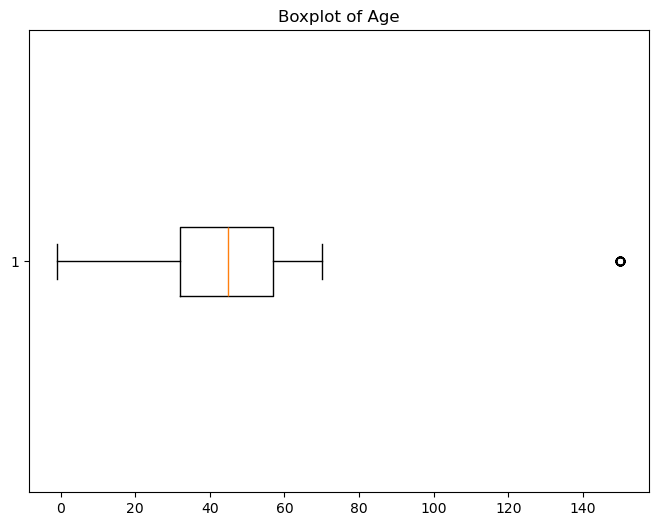

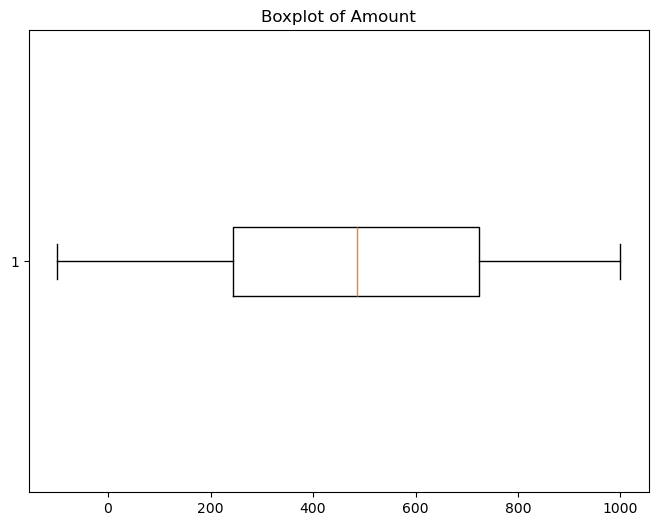

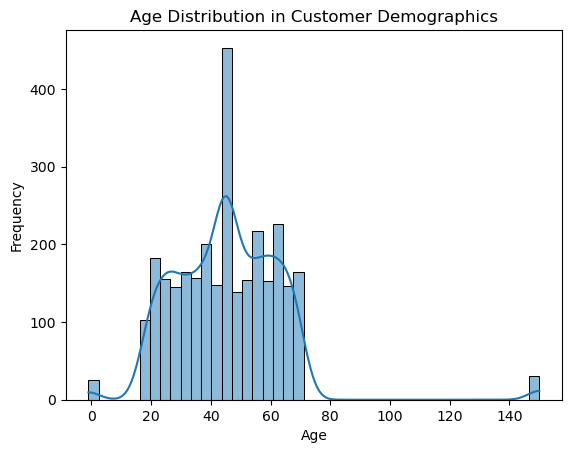

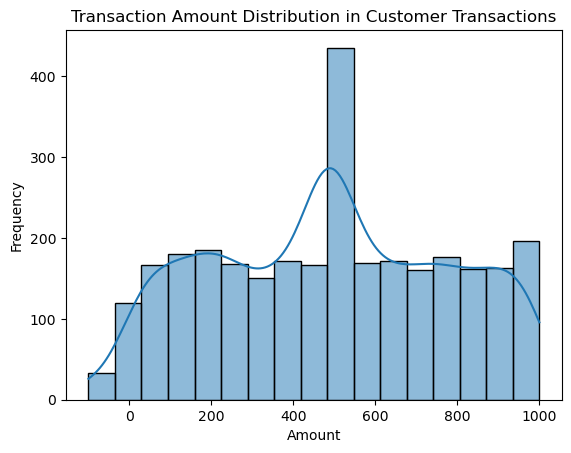

In [43]:
# Boxplot for 'Age' in customer demographics
plt.figure(figsize=(8, 6))
plt.boxplot(standardized_data1['Age'].dropna(), vert=False)
plt.title('Boxplot of Age')
plt.show()

# Boxplot for 'Amount' in customer transactions
plt.figure(figsize=(8, 6))
plt.boxplot(standardized_data2['Amount'].dropna(), vert=False)
plt.title('Boxplot of Amount')
plt.show()


sns.histplot(standardized_data1['Age'].dropna(), kde=True)
plt.title("Age Distribution in Customer Demographics")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Plotting distribution of 'Amount' in customer transactions (data2)
sns.histplot(standardized_data2['Amount'].dropna(), kde=True)
plt.title("Transaction Amount Distribution in Customer Transactions")
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


Age Outliers (Customer Demographics)
Minimum Age = -1; frequency = 26
Interpretation: clearly an error, as age cannot be negative; values are likely to be data entry errors (e.g., a typo or miscapture)
Handling: Deletion - Since negative age represents a small fraction (0.88%) of the dataset

Age Outliers (Customer Demographics)
Maximum Age = 150; frequency = 31
Interpretation: clearly an error, as oldest person verified was aged 122;; values are likely to be data entry errors (e.g., a typo or miscapture)
Handling: Deletion - Since negative age represents a small fraction (1.05%) of the dataset

Transaction Amount Outliers (Customer Transactions)
Minimum Amount = -100; frequency = 33
Interpretation: seems to represent an invalid transaction (as negative amounts are typically not valid unless there was a refund or a discount). 
Handling: 1. Review if customers have other transactions that are of the same or close transaction date and of the same category.
2. Deletion - Since negative age represents a small fraction (1.11%) of the dataset and some customers don’t have any other transactions whereby some that appears to have another transaction, either transaction dates are too far apart and/or the product category are different

In [45]:
# Load the customer transactions dataset
standardized_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_standardized.csv')

# Step 1: Identify CustomerIDs with -100 transaction amounts
customers_with_negative_amount = standardized_data2[standardized_data2['Amount'] == -100]['CustomerID'].unique()

# Step 2: Pull all transactions for those customers
filtered_transactions = standardized_data2[standardized_data2['CustomerID'].isin(customers_with_negative_amount)]

# Step 3: Group by CustomerID for easier comparison
grouped_transactions = filtered_transactions.groupby('CustomerID')

# To display the results for each customer
for customer_id, group in grouped_transactions:
    print(f"\nCustomerID: {customer_id}")
    print(group)


CustomerID: 03fac2e6-f130-4cf6-b8b8-2f147c2fe60a
                                CustomerID                         TransactionID TransactionDate  Amount ProductCategory  PaymentMethod
779   03fac2e6-f130-4cf6-b8b8-2f147c2fe60a  49fd87f6-e44a-4ed8-8bb2-b47cfd5fdbbc      2023-10-15  175.31      Automotive  Bank Transfer
1224  03fac2e6-f130-4cf6-b8b8-2f147c2fe60a  6f57c9c3-0c11-4d34-9392-08eb6b91fd0e      2024-05-21 -100.00   Home & Garden     Debit Card

CustomerID: 0e678ba1-7b5f-46aa-8b5a-6dc1190373be
                                CustomerID                         TransactionID TransactionDate  Amount ProductCategory PaymentMethod
2207  0e678ba1-7b5f-46aa-8b5a-6dc1190373be  eb179234-9502-4329-b9dc-412c05b6decf      2022-09-09  796.54        Clothing        PayPal
2439  0e678ba1-7b5f-46aa-8b5a-6dc1190373be  33ce68ea-42c4-48eb-8631-c8f611d2a330      2023-03-01 -100.00        Clothing    Debit Card

CustomerID: 1f5c50db-9c55-4bbc-8a93-c7994a7bb3d3
                                Custo

In [47]:
# Load the datasets
standardized_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_standardized.csv')
standardized_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_standardized.csv')
standardized_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_standardized.csv')

# Define datasets and dataset names
datasets = [standardized_data1, standardized_data2, standardized_data3]
dataset_names = ['customer_demographics', 'customer_transactions', 'social_media_interactions']

# Step 1: Filter out outliers from customer demographics (Age) and customer transactions (Amount)
# Remove rows with Age = -1 or Age = 150 from data1
final_cleaned_data1 = standardized_data1[~standardized_data1['Age'].isin([-1, 150])]

# Remove rows with Amount = -100 from data2
final_cleaned_data2 = standardized_data2[standardized_data2['Amount'] != -100]

# No outliers for data3, so we copy as is.
final_cleaned_data3 = standardized_data3.copy()

# Step 2: Save the cleaned datasets with the "_final_cleaned" suffix
final_cleaned_data1.to_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_final_cleaned.csv', index=False)
final_cleaned_data2.to_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_final_cleaned.csv', index=False)
final_cleaned_data3.to_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_final_cleaned.csv', index=False)

print("Outliers have been removed and the final cleaned datasets have been saved.")


Outliers have been removed and the final cleaned datasets have been saved.


In [49]:
# Load the cleaned datasets
final_cleaned_data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_demographics_final_cleaned.csv')
final_cleaned_data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/customer_transactions_final_cleaned.csv')
final_cleaned_data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/social_media_interactions_final_cleaned.csv')

# Merge datasets on 'CustomerID'
# Merge customer demographics with customer transactions
transaction_behavior_df = pd.merge(final_cleaned_data1.copy(), final_cleaned_data2.copy(), on='CustomerID', how='inner')

# Merge customer demographics with social media interactions
socmed_behavior_df = pd.merge(final_cleaned_data1.copy(), final_cleaned_data3.copy(), on='CustomerID', how='inner')

# Step 3: Save the final joined dataset
transaction_behavior_df.to_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/transaction_behavior.csv', index=False)
socmed_behavior_df.to_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/socmed_behavior.csv', index=False)
print("Datasets have been successfully joined and saved.")

Datasets have been successfully joined and saved.


In [51]:
transaction_behavior = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/transaction_behavior.csv')
socmed_behavior = pd.read_csv('/Users/fritzcabalhin/Desktop/2. Machine Learning/Codes/eda/socmed_behavior.csv')

datasets = [transaction_behavior.copy(), socmed_behavior.copy()]
dataset_names = ['finmark_transaction_behavior','finmark_socmed_behavior']

for df, dataset_name in zip(datasets, dataset_names):
    print(f"{dataset_name} has {df.shape[1]} columns and {df.shape[0]} rows.")

finmark_transaction_behavior has 11 columns and 2853 rows.
finmark_socmed_behavior has 11 columns and 2875 rows.


In [53]:
transaction_behavior.head(5)

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
0,9207fa75-5758-48d1-94ad-19c041e0520f,51,Female,Jensenberg,Low,2022-11-17,504a03b0-294d-4e3c-9bf7-46935ba6c47a,2023-01-22,486.49,Clothing,Debit Card
1,9207fa75-5758-48d1-94ad-19c041e0520f,51,Female,Jensenberg,Low,2022-11-17,d4922534-dfd9-47d9-8fc8-d0421284b682,2022-09-14,660.87,Home & Garden,Bank Transfer
2,5fb09cd8-a473-46f7-80bd-6e49cf509078,45,Female,Castilloport,High,2020-07-21,99917043-698e-4753-a1fb-61b4afdd4da3,2022-11-11,976.88,Electronics,PayPal
3,c139496e-cc89-498a-bd90-1fb4627b6cff,37,Male,Lake Jennifertown,High,2021-01-01,7ec0b3f7-167f-409f-bc42-4053d32b1d32,2023-06-24,528.32,Health & Beauty,PayPal
4,7d1f2bbc-8d16-4fbc-9b37-ece3324e8ed4,50,Female,Jessebury,High,2023-08-24,1c31455b-ee29-430d-b9c8-171ee90f90ba,2024-05-22,733.46,Automotive,PayPal


In [55]:
socmed_behavior.head(5)

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,9207fa75-5758-48d1-94ad-19c041e0520f,51,Female,Jensenberg,Low,2022-11-17,0626cfe9-8e7f-4b19-ba9b-21330cd007c8,2024-01-11,Instagram,Comment,Negative
1,9207fa75-5758-48d1-94ad-19c041e0520f,51,Female,Jensenberg,Low,2022-11-17,20320eb9-5f38-41f5-b855-e0a0880d8c46,2023-08-25,Facebook,Share,Positive
2,5fb09cd8-a473-46f7-80bd-6e49cf509078,45,Female,Castilloport,High,2020-07-21,3d962e49-3930-4131-aa8f-ad8753338770,2024-01-01,Instagram,Share,Positive
3,5fb09cd8-a473-46f7-80bd-6e49cf509078,45,Female,Castilloport,High,2020-07-21,eb016f64-afd0-4bd7-85e6-7b136b3c6e8c,2023-12-02,Instagram,Share,Negative
4,50118139-7264-428f-81cc-a25fddc5d6dd,44,Male,Port Carl,Medium,2024-06-10,b269b17c-a777-4670-a566-905607050ee1,2023-11-07,Facebook,Share,Neutral
